Bu amaliy vazifada siz o‘tgan darslarda olgan bilimlaringizni sinovdan o‘tkazasiz. Shu yo‘l bilan o‘zingizda bu ko‘nikmalarni rivojlantirasiz. Chunki ularni egallash uchun faqatgina videodarslarni ko‘rish yetarli bo‘lmaydi. Amaliy vazifalarni Google Colab’da bajarishingiz mumkin. Quyida uni bajarish bo‘yicha aniq ko‘rsatmalar berilgan. Ko‘rsatmalarni aniq bajarib, o‘z bilimlaringizni sinovdan o‘tkazing. ❗️Bu amaliy vazifa o‘z ko‘nikmalaringizda mustaqil ishlash uchun berilgan va baholanmaydi. Agar sizda savol tug‘ilsa, Telegram guruhda mentordan yordam olishingiz mumkin. Bundan tashqari modul oxirida yana bir katta amaliy vazifa bo‘ladi. U barcha mavzularni qamrab oladi va kurs mentori tomonidan baholanadi.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Qurilma:", device)
print("PyTorch versiyasi:", torch.__version__)

Qurilma: cpu
PyTorch versiyasi: 2.11.0+cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),                      # PIL rasm → tensor, piksellar [0,1] ga
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST'ning mean va std qiymatlari
])

In [22]:
train_dataset = torchvision.datasets.MNIST(
    root="./data",          # qayerga saqlansin
    train=True,             # o'rgatish to'plami
    transform=transform,    # yuqorida yozgan transform
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,            # test to'plami
    transform=transform,
    download=True
)

print("Train hajmi:", len(train_dataset))   # 60000
print("Test hajmi: ", len(test_dataset))    # 10000

# Bitta namunani tekshiramiz: rasm tensori va uning yorlig'i
image, label = train_dataset[0]
print("Rasm o'lchami:", image.shape)        # torch.Size([1, 28, 28])
print("Yorliq:", label)

Train hajmi: 60000
Test hajmi:  10000
Rasm o'lchami: torch.Size([1, 28, 28])
Yorliq: 5


: Dataset'dan bittalab keladigan namunalarni to'plab, batch qilib, model tushunadigan shaklda uzatib turadi.

Dataset — ombor (dataset[0], dataset[1], ... deb bittalab olasan). DataLoader — konveyer: o'zi indekslarni tanlaydi, o'zi yig'adi, o'zi aylantirib beradi.

Uch ish qiladi
1. Indekslarni tartibga soladi (shuffle)

shuffle=True bo'lsa, har epocha boshida 0–59999 indekslari aralashtiriladi. shuffle=False bo'lsa, tartib bo'yicha ketaveradi.

2. Guruhlaydi (batch_size)

Aralashtirilgan indekslarni 64 talab bo'ladi va har bo'lak uchun dataset[i] ni chaqirib, 64 ta namuna yig'adi.

3. Birlashtiradi (collate)

64 ta alohida [1,28,28] tensorni ustma-ust taxlab, bitta [64,1,28,28] tensorga aylantiradi. Yorliqlarni ham: 64 ta alohida int → bitta [64] tensor. Bu ishni torch.stack bajaradi, ichkarida avtomatik.

In [23]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print("Train batchlar soni:", len(train_loader))   # 60000 / 64 ≈ 938

# Bitta batch qanday ko'rinishini tekshiramiz
images, labels = next(iter(train_loader))
print("Batch rasm o'lchami:", images.shape)   # [64, 1, 28, 28]
print("Batch yorliq o'lchami:", labels.shape) # [64]

Train batchlar soni: 938
Batch rasm o'lchami: torch.Size([64, 1, 28, 28])
Batch yorliq o'lchami: torch.Size([64])


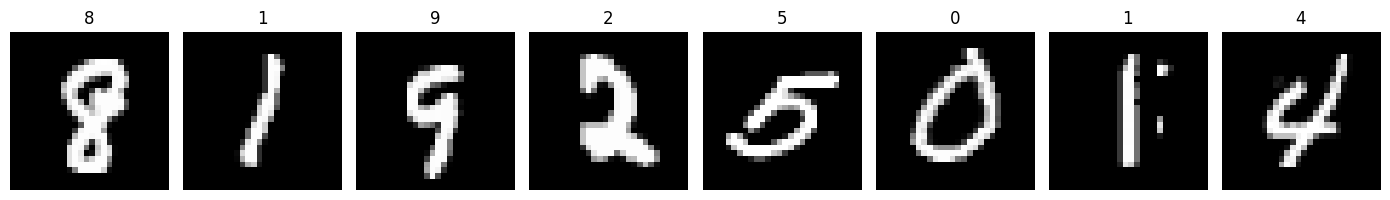

In [25]:
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    # squeeze() — [1,28,28] dan [28,28] ga, chunki imshow 2D kutadi
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f"{labels[i].item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

nn.Flatten() — algoritm emas, shakl o'zgartirish

Bu savolingga aniq javob: Flatten hech narsani hisoblamaydi. Unda vazn yo'q, o'rganadigan narsasi yo'q, matematika yo'q. U faqat tensorning o'lchamlarini qayta joylashtiradi — xotiradagi sonlar o'sha-o'sha qoladi, faqat "shakli" o'zgaradi.

nn.Sequential — qatlamlarni ulash

Sequential shunchaki konteyner: birinchi qatlamning chiqishini ikkinchisiga, uning chiqishini uchinchisiga uzatadi. Hech qanday aql yo'q, faqat ketma-ketlik.

In [26]:
model = nn.Sequential(
    nn.Flatten(),           # [64, 1, 28, 28] → [64, 784]
    nn.Linear(784, 128),    # kiruvchi qatlam → yashirin qatlam
    nn.ReLU(),              # aktivatsiya: manfiylarni 0 qiladi, chiziqsizlik beradi
    nn.Linear(128, 10)      # yashirin qatlam → 10 ta chiqish (0–9 raqamlari)
).to(device)

print(model)

# Nechta o'rganiladigan parametr (vazn + bias) borligini sanaymiz
total = sum(p.numel() for p in model.parameters())
print(f"Jami parametrlar: {total:,}")   # 784*128 + 128 + 128*10 + 10 = 101,770

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)
Jami parametrlar: 101,770


In [8]:
criterion = nn.CrossEntropyLoss()                      # softmax + log-likelihood ichida
optimizer = optim.SGD(model.parameters(), lr=0.01)     # vaznlarni yangilovchi

print(criterion)
print(optimizer)

CrossEntropyLoss()
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [15]:
epochs = 8
loss_history = []          # har epochaning o'rtacha loss'i shu yerga yig'iladi

model.train()              # modelni o'qitish rejimiga o'tkazamiz

for epoch in range(epochs):
    running_loss = 0.0     # shu epochadagi barcha batch loss'lari yig'indisi

    for images, labels in train_loader:
        # Ma'lumotni GPU/CPU ga ko'chiramiz
        images, labels = images.to(device), labels.to(device)

        # 1) Oldingi qadamdan qolgan gradientlarni tozalaymiz.
        #    Bu qator bo'lmasa gradientlar qo'shilib ketadi — eng ko'p uchraydigan xato.
        optimizer.zero_grad()

        # 2) Forward: model bashorat qiladi (10 ta "xom" ball — logits)
        outputs = model(images)

        # 3) Xatoni o'lchaymiz
        loss = criterion(outputs, labels)

        # 4) Backward: har bir vazn uchun gradient hisoblanadi (backpropagation)
        loss.backward()

        # 5) Optimayzer vaznlarni yangilaydi
        optimizer.step()

        # loss.item() — tensordan oddiy songa aylantiradi
        running_loss += loss.item()

    # Epochaning o'rtacha loss'i = yig'indi / batchlar soni
    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)

    print(f"Epocha {epoch+1}/{epochs}  —  o'rtacha loss: {epoch_loss:.4f}")

print("\nO'qitish tugadi.")

Epocha 1/8  —  o'rtacha loss: 0.1758
Epocha 2/8  —  o'rtacha loss: 0.1594
Epocha 3/8  —  o'rtacha loss: 0.1464
Epocha 4/8  —  o'rtacha loss: 0.1350
Epocha 5/8  —  o'rtacha loss: 0.1253
Epocha 6/8  —  o'rtacha loss: 0.1170
Epocha 7/8  —  o'rtacha loss: 0.1098
Epocha 8/8  —  o'rtacha loss: 0.1033

O'qitish tugadi.


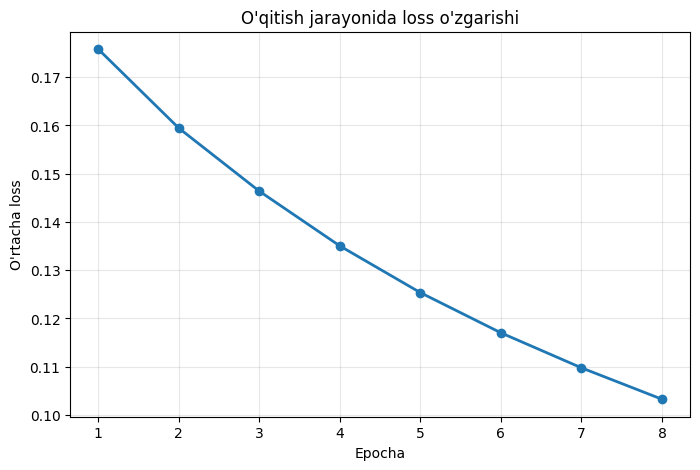

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), loss_history, marker="o", linewidth=2)
plt.xlabel("Epocha")
plt.ylabel("O'rtacha loss")
plt.title("O'qitish jarayonida loss o'zgarishi")
plt.xticks(range(1, epochs+1))
plt.grid(alpha=0.3)
plt.show()

In [17]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        # argmax — 10 ta balldan eng kattasining indeksi = bashorat qilingan raqam
        _, predicted = torch.max(outputs, 1)

        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test aniqligi: {100 * correct / total:.2f}%")

Test aniqligi: 96.54%


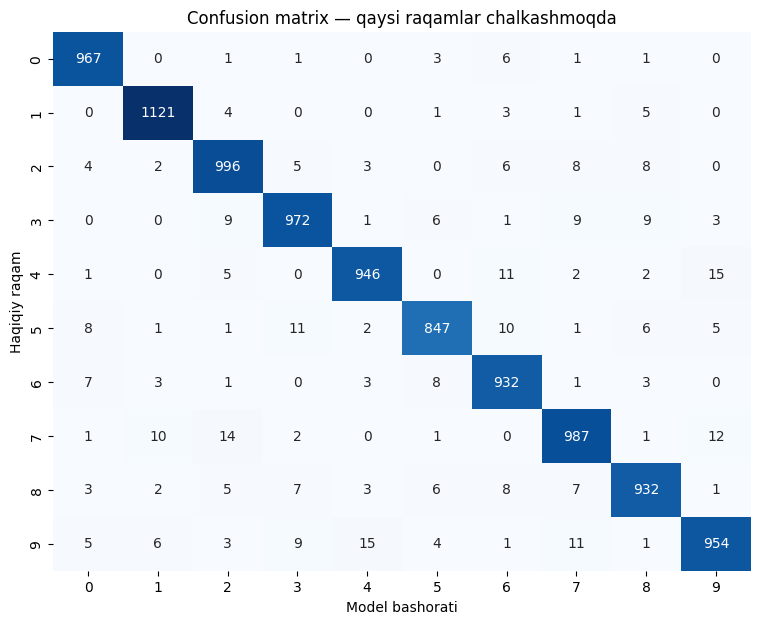

              precision    recall  f1-score   support

           0      0.971     0.987     0.979       980
           1      0.979     0.988     0.983      1135
           2      0.959     0.965     0.962      1032
           3      0.965     0.962     0.964      1010
           4      0.972     0.963     0.968       982
           5      0.967     0.950     0.958       892
           6      0.953     0.973     0.963       958
           7      0.960     0.960     0.960      1028
           8      0.963     0.957     0.960       974
           9      0.964     0.945     0.954      1009

    accuracy                          0.965     10000
   macro avg      0.965     0.965     0.965     10000
weighted avg      0.965     0.965     0.965     10000



In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        # CPU ga qaytarib, numpy ro'yxatiga yig'amiz
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Model bashorati")
plt.ylabel("Haqiqiy raqam")
plt.title("Confusion matrix — qaysi raqamlar chalkashmoqda")
plt.show()

print(classification_report(all_labels, all_preds, digits=3))

Jami xato: 346 ta (3.46%)


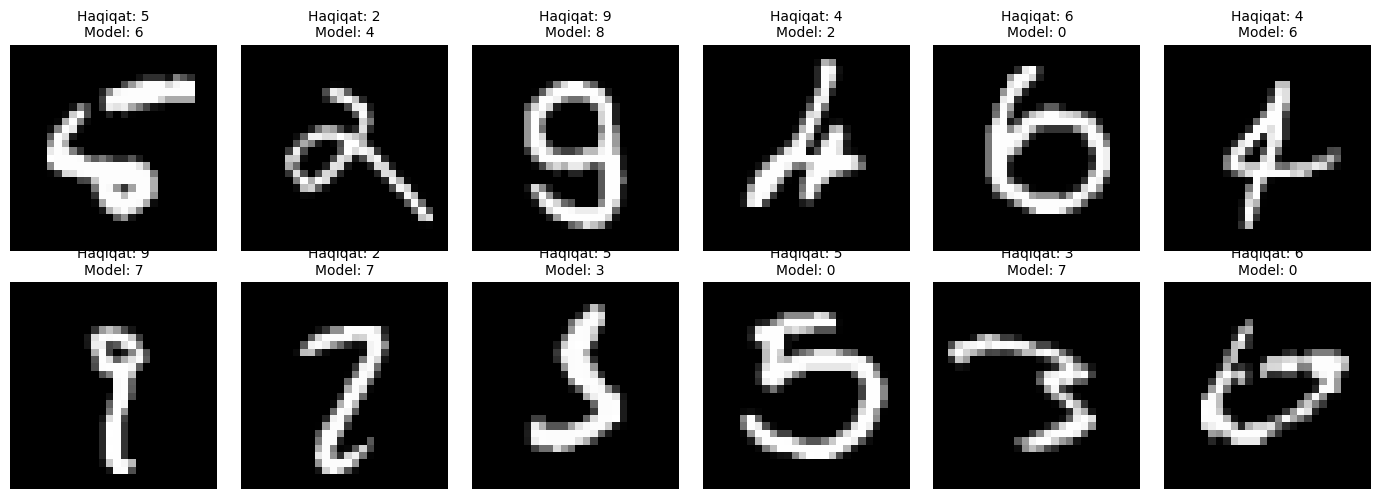

In [19]:
# Xato qilingan indekslarni topamiz
wrong_idx = np.where(all_preds != all_labels)[0]
print(f"Jami xato: {len(wrong_idx)} ta ({len(wrong_idx)/len(all_labels)*100:.2f}%)")

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, idx in zip(axes.flat, wrong_idx[:12]):
    image, true_label = test_dataset[idx]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Haqiqat: {true_label}\nModel: {all_preds[idx]}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()